In [2]:
# Install dependencies on colab
!pip install -Uqq fastbook
import fastbook
fastbook.setup_book()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.4/485.4 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 88.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
from fastai.vision.all import *

# Connect to google drive to load images and save model
from google.colab import drive
drive.mount('/content/drive')

path = Path('/content/drive/MyDrive/3rd_Year/ENDG_411/Assignment_3/gestures/')
path.ls()

Mounted at /content/drive


(#2) [Path('/content/drive/MyDrive/3rd_Year/ENDG_411/Assignment_3/gestures/test'),Path('/content/drive/MyDrive/3rd_Year/ENDG_411/Assignment_3/gestures/train')]

In [4]:
ims = get_image_files(path)
ims

(#285) [Path('/content/drive/MyDrive/3rd_Year/ENDG_411/Assignment_3/gestures/test/down/00000000.jpg'),Path('/content/drive/MyDrive/3rd_Year/ENDG_411/Assignment_3/gestures/test/down/00000005.jpg'),Path('/content/drive/MyDrive/3rd_Year/ENDG_411/Assignment_3/gestures/test/down/00000001.jpg'),Path('/content/drive/MyDrive/3rd_Year/ENDG_411/Assignment_3/gestures/test/down/00000002.jpg'),Path('/content/drive/MyDrive/3rd_Year/ENDG_411/Assignment_3/gestures/test/down/00000004.jpg'),Path('/content/drive/MyDrive/3rd_Year/ENDG_411/Assignment_3/gestures/test/down/00000003.jpg'),Path('/content/drive/MyDrive/3rd_Year/ENDG_411/Assignment_3/gestures/test/down/00000007.jpg'),Path('/content/drive/MyDrive/3rd_Year/ENDG_411/Assignment_3/gestures/test/down/00000006.jpg'),Path('/content/drive/MyDrive/3rd_Year/ENDG_411/Assignment_3/gestures/test/down/00000008.jpg'),Path('/content/drive/MyDrive/3rd_Year/ENDG_411/Assignment_3/gestures/test/down/00000009.jpg'),Path('/content/drive/MyDrive/3rd_Year/ENDG_411/Assig

In [5]:
from fastai.vision.all import *

# 1. Data loading and augmentation

Create a DataBlock and DataLoaders using:
- Training and validation images collected in a2
- Use `set_seed()` to obtain reproducible results.
- Use `item_tfms` and/or `batch_tfms`. Set `min_scale` so that gestures are still visible
- Use a batch size of 32

Show a training and a validation batch.
Show augmentations, i.e. `show_batch()` with `unique=True`.

In [6]:
from fastbook import * #get image_files_sorted
gestures = DataBlock(
    blocks=(ImageBlock, CategoryBlock), #image->discrete category
    get_items=get_image_files_sorted, # path->images
    splitter=GrandparentSplitter(train_name='train', valid_name='test'), #how to train-valid split
    get_y=parent_label, # get the label from the directory name
    item_tfms=RandomResizedCrop(224, min_scale=1), # random crop at each iteration, resize to 224x224
    batch_tfms=aug_transforms()) #a set of transformations like  rotation, flipping, perspective warping, brightness changes and contrast changes

set_seed=set_seed(reproducible=True, s=7) #make results reproducible

dls = gestures.dataloaders(path, bs=32)

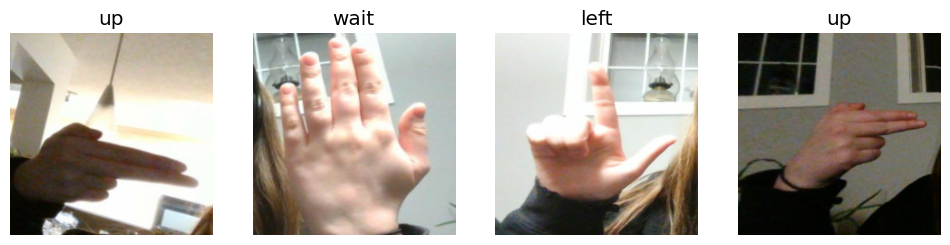

In [7]:
dls.train.show_batch(max_n=4, nrows=1)

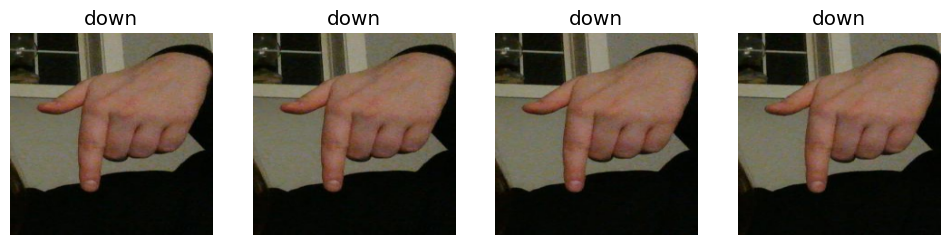

In [8]:
dls.valid.show_batch(max_n=4, nrows=1)

### Question 1: What type of item and batch transforms did you use? Can you spot any problems in the training set augmentations, e.g. gestures not visible?
Some of the gestures were not visible because I originally had min_scale set to 0.5. Then I saw some gestures were getting cut off so I changed min_scale to 1.


# 2. Train the classifier

## 2.1 Impact of learning rate
With:
- Same `set_seed()` as above
- Re-creating the same DataLoaders as above
- ResNet18 architecture.
- error rate as metric.

Use three learning rates:
- small: 3e-5
- medium: 3e-3
- large: 1e-1

Train the model with each learning rate using `fine_tune` with 10-15 epochs


In [9]:
from fastbook import * #get image_files_sorted
gestures = DataBlock(
    blocks=(ImageBlock, CategoryBlock), #image->discrete category
    get_items=get_image_files_sorted, # path->images
    splitter=GrandparentSplitter(train_name='train', valid_name='test'), #how to train-valid split
    get_y=parent_label, # get the label from the directory name
    item_tfms=RandomResizedCrop(224, min_scale=1), # random crop at each iteration, resize to 224x224
    batch_tfms=aug_transforms()) #a set of transformations like  rotation, flipping, perspective warping, brightness changes and contrast changes

set_seed=set_seed(reproducible=True, s=7) #make results reproducible

dls = gestures.dataloaders(path, bs=32)

In [11]:
lrs = {'small': 3e-5, 'medium': 3e-3, 'large': 1e-1} # define the learning rates

# Train the model with each learning rate
for name, lr in lrs.items():
    print(f"Training with {name} learning rate: {lr}")

    learn = vision_learner(dls, resnet18, metrics=error_rate) # reset weights each time
    learn.fine_tune(12, lr) # set epochs and learning rate

Training with small learning rate: 3e-05


epoch,train_loss,valid_loss,error_rate,time
0,2.979183,2.214795,0.920000,01:06


epoch,train_loss,valid_loss,error_rate,time
0,2.838181,2.140892,0.880000,01:11
1,2.899886,2.127063,0.840000,01:10
2,2.784633,2.084184,0.800000,01:09
3,2.780954,2.017555,0.720000,01:08
4,2.743214,1.957943,0.660000,01:08
5,2.690761,1.915218,0.640000,01:08
6,2.589749,1.874983,0.660000,01:09
7,2.496761,1.859132,0.660000,01:08
8,2.490005,1.737597,0.580000,01:08
9,2.441044,1.780653,0.600000,01:07


Training with medium learning rate: 0.003


epoch,train_loss,valid_loss,error_rate,time
0,1.749926,1.456491,0.680000,00:48


epoch,train_loss,valid_loss,error_rate,time
0,0.205352,0.449081,0.200000,01:08
1,0.145991,0.198647,0.060000,01:09
2,0.096940,0.175043,0.060000,01:08
3,0.069270,0.084623,0.060000,01:08
4,0.054066,0.023397,0.000000,01:09
5,0.042273,0.017158,0.000000,01:09
6,0.034173,0.014970,0.000000,01:09
7,0.030467,0.010513,0.000000,01:09
8,0.025880,0.010757,0.000000,01:09
9,0.021683,0.013826,0.000000,01:09


Training with large learning rate: 0.1


epoch,train_loss,valid_loss,error_rate,time
0,0.877828,3.974701,0.520000,00:48


epoch,train_loss,valid_loss,error_rate,time
0,0.686236,11.961368,0.600000,01:08
1,0.575759,10.139717,0.380000,01:09
2,0.624816,0.000000,0.000000,01:08
3,0.462333,22.586712,0.400000,01:09
4,0.484289,0.153672,0.060000,01:09
5,0.596505,4.947731,0.300000,01:09
6,0.619776,0.000124,0.000000,01:09
7,0.600798,0.000017,0.000000,01:11
8,0.555603,0.000959,0.000000,01:09
9,0.466586,0.000002,0.000000,01:09


### Question 2: Which training run resulted in the best model? State number of epochs and final error rate values for all learning rates and identify the best model.
The training run that resulted in the best model was the medium learning rate because it had the lowest final error rate after 12 epochs. Here is a table summarizing the performance of the models:
| Learning Rate | Epochs | Final Error Rate |
|---------------|--------|------------------|
| small         | 12     | 0.58             |
| medium        | 12     | 0.00             |
| large         | 12     | 0.00             |


### Question 3: Did any models overfit? Include your reasoning.
I think the model with the largest learning rate might have overfit. It could have overfit because the validation loss and error rate are quite erratic. On the other hand, the training loss is not super low, even at the end of 12 epochs so it could be that the model is just bad, not overfitting.


# 3. Analyze model performance
- Retrain the best model from above.
- Plot the confusion matrix.
- Plot 10 top losses

In [12]:
    learn = vision_learner(dls, resnet18, metrics=error_rate) # reset weights each time
    learn.fine_tune(7, 3e-3) # set epochs and learning rate

epoch,train_loss,valid_loss,error_rate,time
0,1.622111,1.467547,0.620000,00:49


epoch,train_loss,valid_loss,error_rate,time
0,0.158347,0.291887,0.060000,01:08
1,0.111764,0.030251,0.000000,01:09
2,0.075321,0.015914,0.000000,01:24
3,0.055605,0.027681,0.000000,01:11
4,0.041484,0.015721,0.000000,01:09
5,0.032411,0.016062,0.000000,01:07
6,0.026298,0.014427,0.000000,01:08


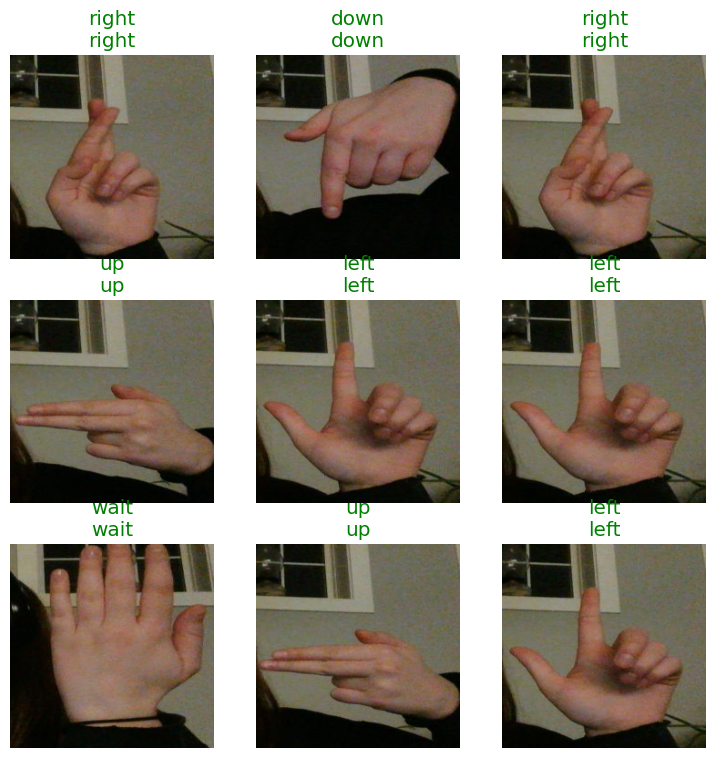

In [13]:
# top: actual
# bottom: predicted
learn.show_results()

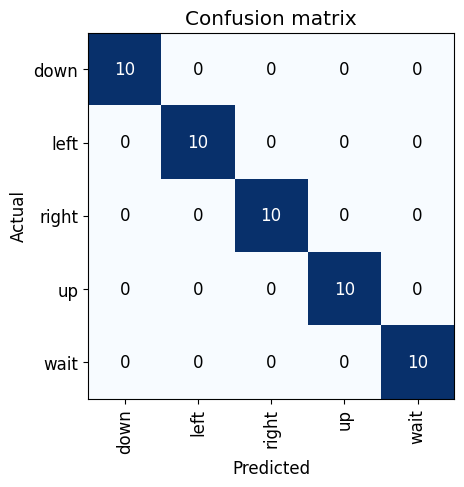

In [14]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

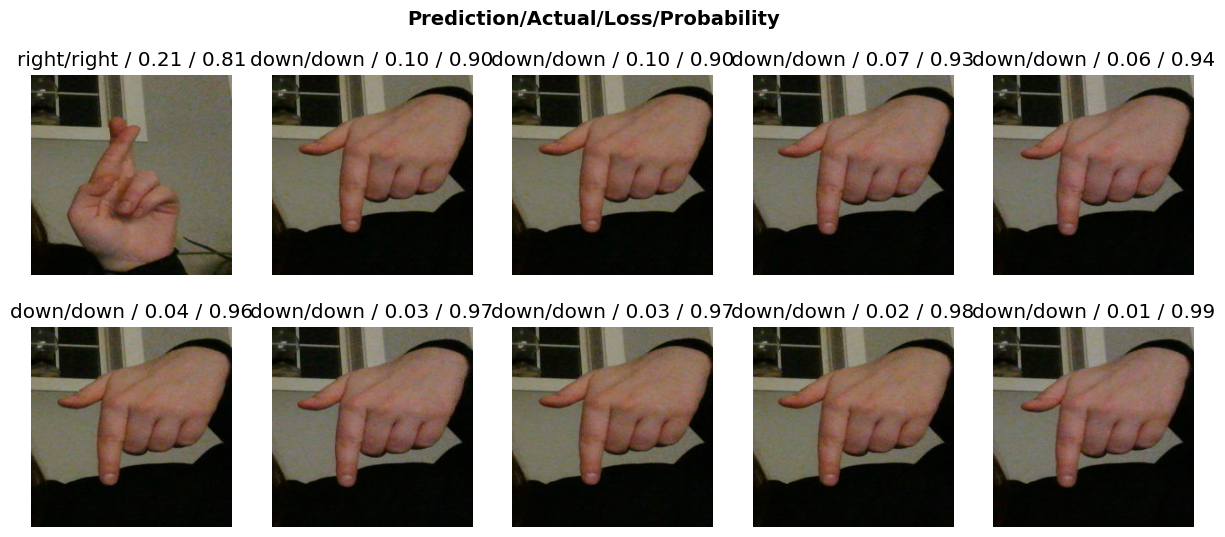

In [15]:
interp.plot_top_losses(10, nrows=2)

### Question 4: With which gestures does your model have the most problems with?
My model has the most problems with the gestures for 'right' and 'down'


# 4. Save the best model to file
Save the model using `learn.export()` as `.pkl` file. Verify that the model can be reloaded and used to make predictions.

In [16]:
learn.export('/content/drive/MyDrive/3rd_Year/ENDG_411/Assignment_3/gestures_model.pkl') # save the model

In [17]:
reload = load_learner('/content/drive/MyDrive/3rd_Year/ENDG_411/Assignment_3/gestures_model.pkl') # load the model

img_path = Path('/content/drive/MyDrive/3rd_Year/ENDG_411/Assignment_3/gestures/test/left/00000000.jpg' ) # Change this to a valid image path
img = PILImage.create(img_path)


Predicted class: left
Probability: 0.9998


<Axes: title={'center': 'Prediction: left'}>

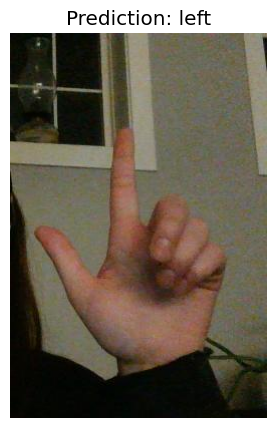

In [19]:
# Make a prediction
pred, pred_idx, probs = reload.predict(img)

# Display results
print(f"Predicted class: {pred}")
print(f"Probability: {probs[pred_idx]:.4f}")

# Show the image
img.show(title=f"Prediction: {pred}")

# 5. Summary and Conclusion

Summarize the best model:
- Training strategy: learning rate and epochs used.
- Error rate achieved, summary of confusion matrix, i.e. what kind of errors does the model make.

The learning rates used were 3e-5, 3e-3, and 1e-1. All three were run for 12 epochs. The model used was the model with the learning rate of 3e-3. The error rate achieved for this model was 0.00 and the model did not make any mistakes.


Conclusion:
- Are you satisfied with model performance? Why, why not?

Yes, I am satisfied with the models performance because it had an error rate of 0.00 and the top losses all had probabilities over 0.8 which I think is pretty good.


# 6.Reflection
Include a sentence or two about
- what you liked or disliked,
- found interesting, confusing, challangeing, motivating

while working on this assignment.

The most difficult part of this assignment was using colab. I did not work consistantly which was very frustrating. Other than that, I enjoyed this assignment.
